<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/top500.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latvia Top-500 companies — analytics (case study)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 20 — A board funds outcomes, options, and controls — not technology  
**Rows:** 8,001  ·  **Source file:** `latvia_top500_companies.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/latvia_top500_companies.csv"
LOCAL = "latvia_top500_companies.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (8001, 14)


,industry_code,industry_name,industry_company_count,industry_rank_turnover,company,reg_no,location,latest_year,turnover_eur,profit_eur,assets_eur,employees,industry_avg_net_salary_eur,page_url
0,1,"Augkopība un lopkopība, medniecība un saistīta...",2483,1,"AS ""Balticovo""",40003058863,Bauskas nov.,2025.0,161551362,35937312,185469370.0,406,1360.735607,https://saraksts.lv/40003058863
1,1,"Augkopība un lopkopība, medniecība un saistīta...",2483,2,"AS ""Ķekava Foods""",50003007411,Ķekavas nov.,2024.0,126483184,7264397,72551814.0,902,1202.812908,https://saraksts.lv/50003007411
2,1,"Augkopība un lopkopība, medniecība un saistīta...",2483,3,"SIA ""GAIŽĒNI""",44101019987,Cēsu nov.,2025.0,17101286,3009832,32019189.0,68,1577.226802,https://saraksts.lv/44101019987
3,1,"Augkopība un lopkopība, medniecība un saistīta...",2483,4,"AS ""ZIEDI JP""",45101000230,Dobeles nov.,2025.0,15633735,2950606,31646894.0,99,943.702943,https://saraksts.lv/45101000230
4,1,"Augkopība un lopkopība, medniecība un saistīta...",2483,5,"AS ""AGROFIRMA TĒRVETE""",45103001086,Dobeles nov.,2025.0,14651784,-1191164,61196393.0,163,1193.817020,https://saraksts.lv/45103001086


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
industry_code                    int64
industry_name                      str
industry_company_count           int64
industry_rank_turnover           int64
company                            str
reg_no                           int64
location                           str
latest_year                    float64
turnover_eur                     int64
profit_eur                       int64
assets_eur                     float64
employees                        int64
industry_avg_net_salary_eur    float64
page_url                           str

Missing values:
latest_year                      52
assets_eur                       52
industry_avg_net_salary_eur    1713


---
## Problem 1 · Easy — describe

Which 5 industries have the highest total turnover? Compute median turnover and median employees per company. Which industry pays the highest average net salary?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Companies: {len(df):,}")
print(f"Total turnover: EUR {df['turnover_eur'].sum()/1e9:,.1f} bn")
print(f"Total employees: {df['employees'].sum():,.0f}")
print("\nTop 10 by turnover:")
print(df.nlargest(10, "turnover_eur")[["company","industry_name","turnover_eur","employees"]]
        .assign(turnover_mn=lambda d: (d.turnover_eur/1e6).round(1))
        .drop(columns="turnover_eur").to_string(index=False))

Companies: 8,001
Total turnover: EUR 17.1 bn
Total employees: 126,874

Top 10 by turnover:
                   company                                                                                                             industry_name  employees  turnover_mn
 AS "Latvijas valsts meži"                                                                                             Mežsaimniecība un mežizstrāde       1443        604.6
    AS "LATVIJAS FINIERIS" Koksnes un koka un korķa izstrādājumu ražošana, izņemot mēbeles; izstrādājumu ražošana no salmiem un pinamiem materiāliem       1500        419.6
          SIA "Mikrotīkls"                                                                          Datoru, elektronisko un optisko iekārtu ražošana        377        326.7
 AS "Dobeles dzirnavnieks"                                                                                                Pārtikas produktu ražošana        471        289.2
      SIA "KRONOSPAN Riga" Koksnes un koka u

---
## Problem 2 · Intermediate — build

Compute revenue-per-employee and net margin (profit/turnover) by industry. Rank industries on both. Where is the "productivity paradox" (high revenue/employee but low margin, or vice versa)?

*Try it yourself first. The worked solution is below.*

In [4]:
ind = (df.groupby("industry_name")
         .agg(companies=("company","size"), turnover=("turnover_eur","sum"),
              employees=("employees","sum"), profit=("profit_eur","sum"))
         .sort_values("turnover", ascending=False))
ind["turnover_mn"] = (ind["turnover"]/1e6).round(0)
ind["margin_%"] = (ind["profit"]/ind["turnover"]*100).round(1)
ind["turnover_per_employee"] = (ind["turnover"]/ind["employees"]).round(0)
print(ind[["companies","turnover_mn","margin_%","turnover_per_employee"]].head(12))

                                                    companies  turnover_mn  margin_%  turnover_per_employee
industry_name                                                                                              
Koksnes un koka un korķa izstrādājumu ražošana,...        500       3557.0       4.0               183177.0
Pārtikas produktu ražošana                                500       2520.0       3.4               138835.0
Mežsaimniecība un mežizstrāde                             500       1905.0      14.1               228421.0
Gatavu metālizstrādājumu ražošana, izņemot mašī...        500       1222.0       3.2                97909.0
Augkopība un lopkopība, medniecība un saistītas...        500       1016.0       9.3               119472.0
Citu nemetālisko minerālu izstrādājumu ražošana           447        801.0       7.5               141325.0
Ķīmisku vielu un ķīmisku produktu ražošana                305        603.0       5.9               199372.0
Datoru, elektronisko un opti

---
## Problem 3 · Advanced — judge

Build the investor decision brief: cluster industries by size/margin/productivity, flag the 3 most attractive and 3 most fragile, and write the caveats (turnover != profit; survivorship — these are TOP firms only, no failed companies).

*Try it yourself first. The worked solution is below.*

In [5]:
d = df[(df.turnover_eur > 0) & (df.employees > 0)].copy()
d["rev_per_emp"] = d["turnover_eur"] / d["employees"]
d["margin"] = d["profit_eur"] / d["turnover_eur"]
print("Revenue per employee (EUR):\n", d["rev_per_emp"].describe().round(0))
print("\nMost productive (>=100 employees):")
print(d[d.employees >= 100].nlargest(8, "rev_per_emp")
        [["company","industry_name","employees","rev_per_emp"]].round(0).to_string(index=False))
print(f"\nCorrelation size vs margin: {d['employees'].corr(d['margin']):.2f}")
print("\nCaveat: a single reporting year, self-declared, and revenue per employee")
print("flatters trading businesses over manufacturers. Compare within an industry.")

Revenue per employee (EUR):
 count        6675.0
mean       107531.0
std        634105.0
min             3.0
25%         25781.0
50%         54760.0
75%        102231.0
max      44576635.0
Name: rev_per_emp, dtype: float64

Most productive (>=100 employees):
                  company                                                                                                             industry_name  employees  rev_per_emp
            SIA "LATGRAN" Koksnes un koka un korķa izstrādājumu ražošana, izņemot mēbeles; izstrādājumu ražošana no salmiem un pinamiem materiāliem        126    1755770.0
         SIA "Mikrotīkls"                                                                          Datoru, elektronisko un optisko iekārtu ražošana        377     866526.0
     SIA "KRONOSPAN Riga" Koksnes un koka un korķa izstrādājumu ražošana, izņemot mēbeles; izstrādājumu ražošana no salmiem un pinamiem materiāliem        270     822829.0
  AS "STORA ENSO LATVIJA" Koksnes un koka un korķa iz

---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


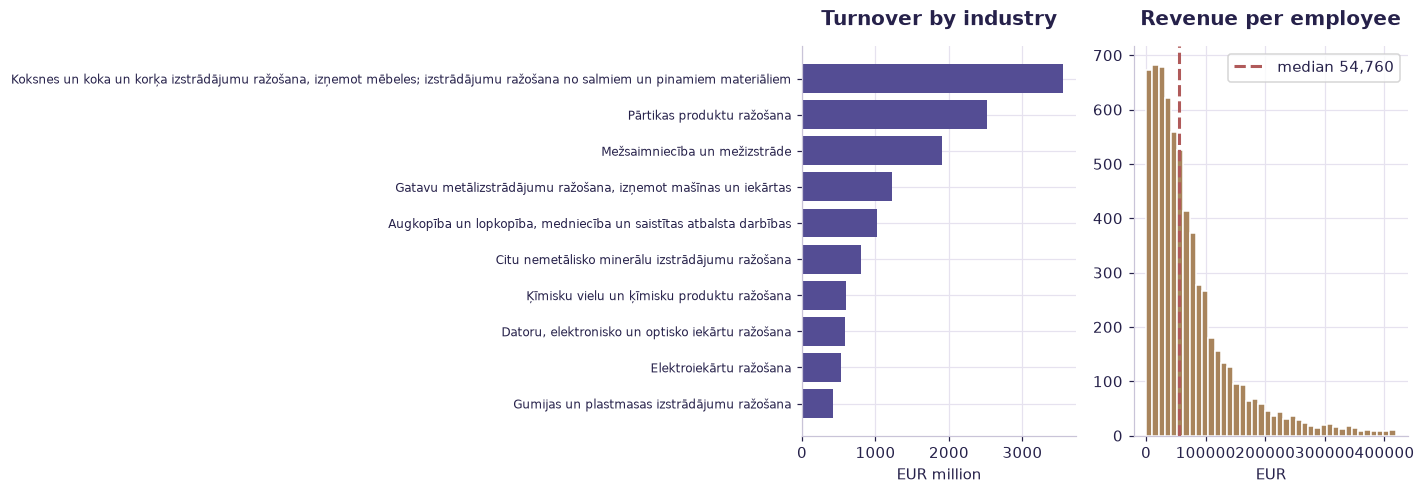

In [6]:
ind = (df.groupby("industry_name")
         .agg(turnover=("turnover_eur","sum"), employees=("employees","sum"))
         .sort_values("turnover").tail(10))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].barh(ind.index, ind["turnover"]/1e6, color=ACCENT)
ax[0].set_title("Turnover by industry"); ax[0].set_xlabel("EUR million")
ax[0].tick_params(axis="y", labelsize=8)

d = df[(df.turnover_eur > 0) & (df.employees > 0)].copy()
d["rpe"] = d.turnover_eur / d.employees
ax[1].hist(d[d.rpe < d.rpe.quantile(.97)]["rpe"], bins=40, color=BUILDER, edgecolor="white")
ax[1].axvline(d.rpe.median(), color=DANGER, ls="--", lw=2, label=f"median {d.rpe.median():,.0f}")
ax[1].set_title("Revenue per employee"); ax[1].set_xlabel("EUR"); ax[1].legend()
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. 8,001 top firms across ~85 industries (top 500 per industry). Median company turnover €282,710
2. Decision-intelligence lesson: rank on revenue-per-employee and MARGIN, not raw turnover — big != profitable
3. Survivorship built in: these are the TOP companies — no bankruptcies — so "average industry health" is overstated
4. Latvian text in industry_name (Augkopiba, Mezsaimnieciba...) — a real multilingual-data + AI-translation exercise


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** The board-ready AI transformation roadmap + your pushback Q&A. This is the course capstone — save it in notes and export it.

---
*Applied AI Academy · appliedai.center*
